# Wine Quality Prediction — Regression

## Project A: Regression with MLflow

The goal of this project is to predict white wine quality as a numerical value
using physicochemical properties.

The project follows an experiment-driven workflow:

- establish simple baselines;
- develop and compare neural networks;
- track experiments with MLflow;
- tune promising configurations;
- select the best model using validation performance;
- evaluate the winner once on the held-out test set;
- register the final model.

## Imports

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn

from mlflow.models import infer_signature

from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

In [2]:
# Constants
RANDOM_STATE = 42

TEST_SIZE = 0.20

# After removing the 20% test set,
# use 25% of the remaining 80% as validation.
# This gives us approximately:
# 60% train / 20% validation / 20% test
VALIDATION_SIZE = 0.25



In [3]:
# mlflow configuration
MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"
EXPERIMENT_NAME = "Wine Quality - Regression"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

experiment = mlflow.set_experiment(
    EXPERIMENT_NAME
)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", experiment.name)
print("Experiment ID:", experiment.experiment_id)

Tracking URI: http://127.0.0.1:5000
Experiment: Wine Quality - Regression
Experiment ID: 1


## EDA

In [4]:
# data 
data = pd.read_csv("https://raw.githubusercontent.com/mlflow/mlflow/master/tests/datasets/winequality-white.csv", sep=";")

In [5]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [6]:
data.shape

(4898, 12)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,4898.0,6.854788,0.843868,3.80000,6.300000,6.80000,7.3000,14.20000
volatile acidity,4898.0,0.278241,0.100795,0.08000,0.210000,0.26000,0.3200,1.10000
citric acid,4898.0,0.334192,0.121020,0.00000,0.270000,0.32000,0.3900,1.66000
residual sugar,4898.0,6.391415,5.072058,0.60000,1.700000,5.20000,9.9000,65.80000
chlorides,4898.0,0.045772,0.021848,0.00900,0.036000,0.04300,0.0500,0.34600
free sulfur dioxide,4898.0,35.308085,17.007137,2.00000,23.000000,34.00000,46.0000,289.00000
total sulfur dioxide,4898.0,138.360657,42.498065,9.00000,108.000000,134.00000,167.0000,440.00000
density,4898.0,0.994027,0.002991,0.98711,0.991723,0.99374,0.9961,1.03898
pH,4898.0,3.188267,0.151001,2.72000,3.090000,3.18000,3.2800,3.82000
sulphates,4898.0,0.489847,0.114126,0.22000,0.410000,0.47000,0.5500,1.08000


In [9]:
data.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [10]:
quality_distribution = (
    data["quality"]
    .value_counts()
    .sort_index()
)

quality_distribution

quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64

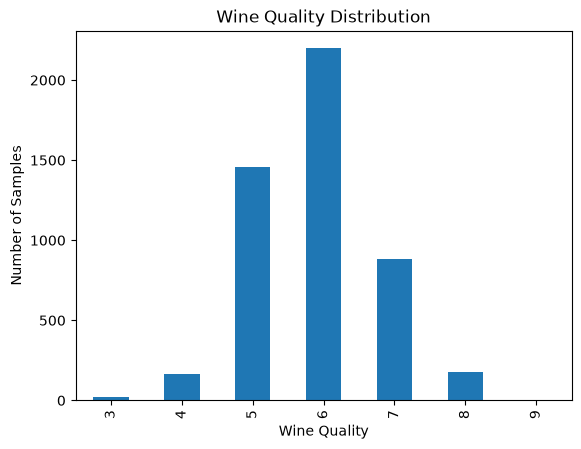

In [11]:
fig, ax = plt.subplots()

quality_distribution.plot(
    kind="bar",
    ax=ax
)

ax.set_xlabel("Wine Quality")
ax.set_ylabel("Number of Samples")
ax.set_title("Wine Quality Distribution")

plt.show()

In [12]:
X = data.drop(
    columns=["quality"]
)

y = data["quality"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (4898, 11)
y shape: (4898,)

Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## Train/Validation/Test Split

In [13]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE
)
print("Train:")
print(X_train.shape, y_train.shape)

print("\nValidation:")
print(X_val.shape, y_val.shape)

print("\nTest:")
print(X_test.shape, y_test.shape)

Train:
(2938, 11) (2938,)

Validation:
(980, 11) (980,)

Test:
(980, 11) (980,)


## MLFLOW Configuration

In [14]:
mlflow.set_tracking_uri(
    MLFLOW_TRACKING_URI
)

experiment = mlflow.set_experiment(
    EXPERIMENT_NAME
)

print(
    "Tracking URI:",
    mlflow.get_tracking_uri()
)

print(
    "Experiment:",
    experiment.name
)

print(
    "Experiment ID:",
    experiment.experiment_id
)

Tracking URI: http://127.0.0.1:5000
Experiment: Wine Quality - Regression
Experiment ID: 1


In [15]:
def regression_metrics(y_true, y_pred):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }

## Experiment 00 - Dummy Regressor

In [16]:
dummy_model = DummyRegressor(
    strategy="mean"
)

with mlflow.start_run(
    run_name="00-DummyRegressor"
):


    # Train


    start_time = time.time()

    dummy_model.fit(
        X_train,
        y_train
    )

    training_time = (
        time.time() - start_time
    )



    # Predictions


    train_predictions = dummy_model.predict(
        X_train
    )

    prediction_start = time.time()

    val_predictions = dummy_model.predict(
        X_val
    )

    prediction_time = (
        time.time() - prediction_start
    )



    # Metrics


    train_metrics = regression_metrics(
        y_train,
        train_predictions
    )

    val_metrics = regression_metrics(
        y_val,
        val_predictions
    )



    # Log parameters


    mlflow.log_params({
        "strategy": "mean",
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "validation_size": VALIDATION_SIZE
    })



    # Log metrics


    mlflow.log_metrics({

        "train_rmse":
            train_metrics["rmse"],

        "train_mae":
            train_metrics["mae"],

        "train_r2":
            train_metrics["r2"],

        "validation_rmse":
            val_metrics["rmse"],

        "validation_mae":
            val_metrics["mae"],

        "validation_r2":
            val_metrics["r2"],

        "training_time":
            training_time,

        "prediction_time":
            prediction_time
    })



    # Tags


    mlflow.set_tags({
        "project": "Project A - Regression",
        "model_type": "DummyRegressor",
        "model_family": "Baseline",
        "dataset": "White Wine Quality",
        "task": "Regression",
        "tuning_method": "None"
    })



    # Model signature


    input_example = X_train.head(5)

    example_prediction = dummy_model.predict(
        input_example
    )

    signature = infer_signature(
        input_example,
        example_prediction
    )



    # Log model


    mlflow.sklearn.log_model(
        sk_model=dummy_model,
        name="dummy_regressor",
        signature=signature,
        input_example=input_example
    )



    # Results


    print("Dummy Regressor")

    print(
        f"\nTrain RMSE:      "
        f"{train_metrics['rmse']:.4f}"
    )

    print(
        f"Validation RMSE: "
        f"{val_metrics['rmse']:.4f}"
    )

    print(
        f"Validation MAE:  "
        f"{val_metrics['mae']:.4f}"
    )

    print(
        f"Validation R²:   "
        f"{val_metrics['r2']:.4f}"
    )

    print(
        f"\nTraining Time:   "
        f"{training_time:.6f} s"
    )

Dummy Regressor

Train RMSE:      0.8937
Validation RMSE: 0.8658
Validation MAE:  0.6602
Validation R²:   -0.0008

Training Time:   0.016771 s
🏃 View run 00-DummyRegressor at: http://127.0.0.1:5000/#/experiments/1/runs/55e716ff76a94cd299d398c6892adcd7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Experiment 01 — Linear Regression

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
# Experiment 01: Linear Regression

linear_model = LinearRegression()

with mlflow.start_run(run_name="01-LinearRegression"):

    start_time = time.time()
    linear_model.fit(X_train, y_train)
    training_time = time.time() - start_time

    train_predictions = linear_model.predict(X_train)

    prediction_start = time.time()
    val_predictions = linear_model.predict(X_val)
    prediction_time = time.time() - prediction_start

    train_metrics = regression_metrics(
        y_train,
        train_predictions
    )

    val_metrics = regression_metrics(
        y_val,
        val_predictions
    )

    mlflow.log_params({
        "fit_intercept": linear_model.fit_intercept,
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "validation_size": VALIDATION_SIZE
    })

    mlflow.log_metrics({
        "train_rmse": train_metrics["rmse"],
        "train_mae": train_metrics["mae"],
        "train_r2": train_metrics["r2"],
        "validation_rmse": val_metrics["rmse"],
        "validation_mae": val_metrics["mae"],
        "validation_r2": val_metrics["r2"],
        "training_time": training_time,
        "prediction_time": prediction_time
    })

    mlflow.set_tags({
        "project": "Project A - Regression",
        "model_type": "LinearRegression",
        "model_family": "Linear Model",
        "dataset": "White Wine Quality",
        "task": "Regression",
        "tuning_method": "None",
        "scaled": "False"
    })

    coefficients = pd.DataFrame({
        "feature": X_train.columns,
        "coefficient": linear_model.coef_
    }).sort_values(
        "coefficient",
        key=abs,
        ascending=False
    )

    mlflow.log_table(
        coefficients,
        "coefficients.json"
    )

    fig, ax = plt.subplots()

    ax.scatter(
        y_val,
        val_predictions,
        alpha=0.4
    )

    minimum = min(
        y_val.min(),
        val_predictions.min()
    )

    maximum = max(
        y_val.max(),
        val_predictions.max()
    )

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    ax.set_xlabel("Actual Quality")
    ax.set_ylabel("Predicted Quality")
    ax.set_title("Linear Regression — Actual vs Predicted")

    mlflow.log_figure(
        fig,
        "plots/actual_vs_predicted.png"
    )

    plt.close(fig)

    residuals = y_val - val_predictions

    fig, ax = plt.subplots()

    ax.scatter(
        val_predictions,
        residuals,
        alpha=0.4
    )

    ax.axhline(
        y=0,
        linestyle="--"
    )

    ax.set_xlabel("Predicted Quality")
    ax.set_ylabel("Residual")
    ax.set_title("Linear Regression — Residuals")

    mlflow.log_figure(
        fig,
        "plots/residuals.png"
    )

    plt.close(fig)

    input_example = X_train.head(5)
    example_prediction = linear_model.predict(input_example)

    signature = infer_signature(
        input_example,
        example_prediction
    )

    mlflow.sklearn.log_model(
        sk_model=linear_model,
        name="linear_regression",
        signature=signature,
        input_example=input_example
    )

    print("Linear Regression")
    print(f"Train RMSE:      {train_metrics['rmse']:.4f}")
    print(f"Validation RMSE: {val_metrics['rmse']:.4f}")
    print(f"Validation MAE:  {val_metrics['mae']:.4f}")
    print(f"Validation R²:   {val_metrics['r2']:.4f}")
    print(f"Training Time:   {training_time:.6f} s")

Linear Regression
Train RMSE:      0.7563
Validation RMSE: 0.7412
Validation MAE:  0.5676
Validation R²:   0.2665
Training Time:   0.003516 s
🏃 View run 01-LinearRegression at: http://127.0.0.1:5000/#/experiments/1/runs/0ced203fe6404145853b868401976f12
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Experiment 02 — Baseline ANN

In [19]:
import tensorflow as tf
import keras
import mlflow.keras

tf.config.optimizer.set_experimental_options({
    "disable_meta_optimizer": True
})

keras.utils.set_random_seed(RANDOM_STATE)

In [20]:
X_train_nn = X_train.to_numpy(dtype="float32")
X_val_nn = X_val.to_numpy(dtype="float32")

y_train_nn = y_train.to_numpy(dtype="float32")
y_val_nn = y_val.to_numpy(dtype="float32")

In [21]:
EPOCHS = 50
BATCH_SIZE = 64
LEARNING_RATE = 0.01
MOMENTUM = 0.0

In [22]:
normalizer = keras.layers.Normalization(axis=-1)
normalizer.adapt(X_train_nn)

ann_model = keras.Sequential([
    keras.Input(shape=(X_train_nn.shape[1],)),
    normalizer,
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1)
])

ann_model.compile(
    optimizer=keras.optimizers.SGD(
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM
    ),
    loss="mean_squared_error",
    metrics=[
        keras.metrics.RootMeanSquaredError(name="rmse"),
        keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 11)             │            23 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 856 (3.35 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 23 (96.00 B)

In [23]:
with mlflow.start_run(run_name="02-ANN-Baseline"):

    start_time = time.time()

    history = ann_model.fit(
        X_train_nn,
        y_train_nn,
        validation_data=(X_val_nn, y_val_nn),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    training_time = time.time() - start_time

    train_predictions = ann_model.predict(
        X_train_nn,
        verbose=0
    ).ravel()

    prediction_start = time.time()

    val_predictions = ann_model.predict(
        X_val_nn,
        verbose=0
    ).ravel()

    prediction_time = time.time() - prediction_start

    train_metrics = regression_metrics(
        y_train_nn,
        train_predictions
    )

    val_metrics = regression_metrics(
        y_val_nn,
        val_predictions
    )

    mlflow.log_params({
        "architecture": "64-1",
        "hidden_layers": 1,
        "hidden_units": 64,
        "activation": "relu",
        "optimizer": "SGD",
        "learning_rate": LEARNING_RATE,
        "momentum": MOMENTUM,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "normalization": "Keras Normalization",
        "random_state": RANDOM_STATE
    })

    mlflow.log_metrics({
        "train_rmse": train_metrics["rmse"],
        "train_mae": train_metrics["mae"],
        "train_r2": train_metrics["r2"],
        "validation_rmse": val_metrics["rmse"],
        "validation_mae": val_metrics["mae"],
        "validation_r2": val_metrics["r2"],
        "training_time": training_time,
        "prediction_time": prediction_time
    })

    mlflow.set_tags({
        "project": "Project A - Regression",
        "model_type": "Neural Network",
        "model_family": "ANN",
        "dataset": "White Wine Quality",
        "task": "Regression",
        "tuning_method": "None",
        "optimizer": "SGD"
    })

    for epoch in range(EPOCHS):

        mlflow.log_metric(
            "epoch_train_rmse",
            history.history["rmse"][epoch],
            step=epoch + 1
        )

        mlflow.log_metric(
            "epoch_validation_rmse",
            history.history["val_rmse"][epoch],
            step=epoch + 1
        )

        mlflow.log_metric(
            "epoch_train_loss",
            history.history["loss"][epoch],
            step=epoch + 1
        )

        mlflow.log_metric(
            "epoch_validation_loss",
            history.history["val_loss"][epoch],
            step=epoch + 1
        )

    fig, ax = plt.subplots()

    ax.plot(
        history.history["rmse"],
        label="Training RMSE"
    )

    ax.plot(
        history.history["val_rmse"],
        label="Validation RMSE"
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("RMSE")
    ax.set_title("Baseline ANN — Learning Curve")
    ax.legend()

    mlflow.log_figure(
        fig,
        "plots/learning_curve.png"
    )

    plt.close(fig)

    fig, ax = plt.subplots()

    ax.scatter(
        y_val_nn,
        val_predictions,
        alpha=0.4
    )

    minimum = min(
        y_val_nn.min(),
        val_predictions.min()
    )

    maximum = max(
        y_val_nn.max(),
        val_predictions.max()
    )

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    ax.set_xlabel("Actual Quality")
    ax.set_ylabel("Predicted Quality")
    ax.set_title("Baseline ANN — Actual vs Predicted")

    mlflow.log_figure(
        fig,
        "plots/actual_vs_predicted.png"
    )

    plt.close(fig)

    residuals = y_val_nn - val_predictions

    fig, ax = plt.subplots()

    ax.scatter(
        val_predictions,
        residuals,
        alpha=0.4
    )

    ax.axhline(
        y=0,
        linestyle="--"
    )

    ax.set_xlabel("Predicted Quality")
    ax.set_ylabel("Residual")
    ax.set_title("Baseline ANN — Residuals")

    mlflow.log_figure(
        fig,
        "plots/residuals.png"
    )

    plt.close(fig)

input_example = X_train_nn[:5]

example_prediction = ann_model.predict(
    input_example,
    verbose=0
)

signature = infer_signature(
    input_example,
    example_prediction
)

mlflow.keras.log_model(
    model=ann_model,
    name="baseline_ann",
    signature=signature
)

input_example_df = pd.DataFrame(
    input_example,
    columns=X_train.columns
)

mlflow.log_table(
    input_example_df,
    "input_example.json"
)

print("Baseline ANN")
print(f"Train RMSE:      {train_metrics['rmse']:.4f}")
print(f"Validation RMSE: {val_metrics['rmse']:.4f}")
print(f"Validation MAE:  {val_metrics['mae']:.4f}")
print(f"Validation R²:   {val_metrics['r2']:.4f}")
print(f"Training Time:   {training_time:.4f} s")
print(f"Prediction Time: {prediction_time:.6f} s")

🏃 View run 02-ANN-Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/81eedafaaebd4e1e8de510dd2f487a04
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Baseline ANN
Train RMSE:      0.6876
Validation RMSE: 0.6763
Validation MAE:  0.5191
Validation R²:   0.3895
Training Time:   3.1691 s
Prediction Time: 0.046331 s


## Experiment 03 — Optimizer comparison

In [24]:
def build_ann(optimizer):

    keras.utils.set_random_seed(RANDOM_STATE)

    normalizer = keras.layers.Normalization(axis=-1)
    normalizer.adapt(X_train_nn)

    model = keras.Sequential([
        keras.Input(shape=(X_train_nn.shape[1],)),
        normalizer,
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(1)
    ])

    model.compile(
        optimizer=optimizer,
        loss="mean_squared_error",
        metrics=[
            keras.metrics.RootMeanSquaredError(name="rmse"),
            keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )

    return model

### Experiment 03A — Adam

In [27]:
while mlflow.active_run() is not None:
    print("Ending run:", mlflow.active_run().info.run_id)
    mlflow.end_run()

print("Active run:", mlflow.active_run())

Ending run: ad5a086ea24340639a3f352b02df319e
🏃 View run righteous-newt-860 at: http://127.0.0.1:5000/#/experiments/1/runs/ad5a086ea24340639a3f352b02df319e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Active run: None


In [25]:
adam_model = build_ann(
    keras.optimizers.Adam(
        learning_rate=0.001
    )
)

In [28]:
with mlflow.start_run(run_name="03A-ANN-Adam"):

    start_time = time.time()

    history = adam_model.fit(
        X_train_nn,
        y_train_nn,
        validation_data=(X_val_nn, y_val_nn),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    training_time = time.time() - start_time

    train_predictions = adam_model.predict(
        X_train_nn,
        verbose=0
    ).ravel()

    prediction_start = time.time()

    val_predictions = adam_model.predict(
        X_val_nn,
        verbose=0
    ).ravel()

    prediction_time = time.time() - prediction_start

    train_metrics = regression_metrics(
        y_train_nn,
        train_predictions
    )

    val_metrics = regression_metrics(
        y_val_nn,
        val_predictions
    )

    mlflow.log_params({
        "architecture": "64-1",
        "hidden_layers": 1,
        "hidden_units": 64,
        "activation": "relu",
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "normalization": "Keras Normalization",
        "random_state": RANDOM_STATE
    })

    mlflow.log_metrics({
        "train_rmse": train_metrics["rmse"],
        "train_mae": train_metrics["mae"],
        "train_r2": train_metrics["r2"],
        "validation_rmse": val_metrics["rmse"],
        "validation_mae": val_metrics["mae"],
        "validation_r2": val_metrics["r2"],
        "training_time": training_time,
        "prediction_time": prediction_time
    })

    mlflow.set_tags({
        "project": "Project A - Regression",
        "model_type": "Neural Network",
        "model_family": "ANN",
        "dataset": "White Wine Quality",
        "task": "Regression",
        "tuning_method": "Manual",
        "experiment_focus": "Optimizer",
        "optimizer": "Adam"
    })

    for epoch in range(EPOCHS):

        mlflow.log_metric(
            "epoch_train_rmse",
            history.history["rmse"][epoch],
            step=epoch + 1
        )

        mlflow.log_metric(
            "epoch_validation_rmse",
            history.history["val_rmse"][epoch],
            step=epoch + 1
        )

    fig, ax = plt.subplots()

    ax.plot(
        history.history["rmse"],
        label="Training RMSE"
    )

    ax.plot(
        history.history["val_rmse"],
        label="Validation RMSE"
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("RMSE")
    ax.set_title("ANN with Adam — Learning Curve")
    ax.legend()

    mlflow.log_figure(
        fig,
        "plots/learning_curve.png"
    )

    plt.close(fig)

    input_example = X_train_nn[:5]

    signature = infer_signature(
        input_example,
        adam_model.predict(
            input_example,
            verbose=0
        )
    )

    mlflow.keras.log_model(
        model=adam_model,
        name="ann_adam",
        signature=signature
    )

    input_example_df = pd.DataFrame(
        input_example,
        columns=X_train.columns
    )

    mlflow.log_table(
        input_example_df,
        "input_example.json"
    )

    print("ANN — Adam")
    print(f"Train RMSE:      {train_metrics['rmse']:.4f}")
    print(f"Validation RMSE: {val_metrics['rmse']:.4f}")
    print(f"Validation MAE:  {val_metrics['mae']:.4f}")
    print(f"Validation R²:   {val_metrics['r2']:.4f}")
    print(f"Training Time:   {training_time:.4f} s")

ANN — Adam
Train RMSE:      0.6935
Validation RMSE: 0.6869
Validation MAE:  0.5358
Validation R²:   0.3702
Training Time:   3.1343 s
🏃 View run 03A-ANN-Adam at: http://127.0.0.1:5000/#/experiments/1/runs/2b10bd8653fc43c7ab488ab462780205
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


### Experiment 03B — RMSprop

In [ ]:
rmsprop_model = build_ann(
    keras.optimizers.RMSprop(
        learning_rate=0.001
    )
)

In [30]:
with mlflow.start_run(run_name="03B-ANN-RMSprop"):

    start_time = time.time()

    history = adam_model.fit(
        X_train_nn,
        y_train_nn,
        validation_data=(X_val_nn, y_val_nn),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    training_time = time.time() - start_time

    train_predictions = adam_model.predict(
        X_train_nn,
        verbose=0
    ).ravel()

    prediction_start = time.time()

    val_predictions = adam_model.predict(
        X_val_nn,
        verbose=0
    ).ravel()

    prediction_time = time.time() - prediction_start

    train_metrics = regression_metrics(
        y_train_nn,
        train_predictions
    )

    val_metrics = regression_metrics(
        y_val_nn,
        val_predictions
    )

    mlflow.log_params({
        "architecture": "64-1",
        "hidden_layers": 1,
        "hidden_units": 64,
        "activation": "relu",
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "normalization": "Keras Normalization",
        "random_state": RANDOM_STATE
    })

    mlflow.log_metrics({
        "train_rmse": train_metrics["rmse"],
        "train_mae": train_metrics["mae"],
        "train_r2": train_metrics["r2"],
        "validation_rmse": val_metrics["rmse"],
        "validation_mae": val_metrics["mae"],
        "validation_r2": val_metrics["r2"],
        "training_time": training_time,
        "prediction_time": prediction_time
    })

    mlflow.set_tags({
        "project": "Project A - Regression",
        "model_type": "Neural Network",
        "model_family": "ANN",
        "dataset": "White Wine Quality",
        "task": "Regression",
        "tuning_method": "Manual",
        "experiment_focus": "Optimizer",
        "optimizer": "RMSprop"
    })

    for epoch in range(EPOCHS):

        mlflow.log_metric(
            "epoch_train_rmse",
            history.history["rmse"][epoch],
            step=epoch + 1
        )

        mlflow.log_metric(
            "epoch_validation_rmse",
            history.history["val_rmse"][epoch],
            step=epoch + 1
        )

    fig, ax = plt.subplots()

    ax.plot(
        history.history["rmse"],
        label="Training RMSE"
    )

    ax.plot(
        history.history["val_rmse"],
        label="Validation RMSE"
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("RMSE")
    ax.set_title("ANN with Adam — Learning Curve")
    ax.legend()

    mlflow.log_figure(
        fig,
        "plots/learning_curve.png"
    )

    plt.close(fig)

    input_example = X_train_nn[:5]

    signature = infer_signature(
        input_example,
        adam_model.predict(
            input_example,
            verbose=0
        )
    )

    mlflow.keras.log_model(
        model=adam_model,
        name="ann_rmsprop",
        signature=signature
    )

    input_example_df = pd.DataFrame(
        input_example,
        columns=X_train.columns
    )

    mlflow.log_table(
        input_example_df,
        "input_example.json"
    )

    print("ANN — RMSprop")
    print(f"Train RMSE:      {train_metrics['rmse']:.4f}")
    print(f"Validation RMSE: {val_metrics['rmse']:.4f}")
    print(f"Validation MAE:  {val_metrics['mae']:.4f}")
    print(f"Validation R²:   {val_metrics['r2']:.4f}")
    print(f"Training Time:   {training_time:.4f} s")

ANN — RMSprop
Train RMSE:      0.6447
Validation RMSE: 0.6774
Validation MAE:  0.5323
Validation R²:   0.3875
Training Time:   2.6266 s
🏃 View run 03B-ANN-RMSprop at: http://127.0.0.1:5000/#/experiments/1/runs/f8f0e3e0e7ed4d03b736d93cc1e8b0ad
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Experiment 04 — Architecture Comparison

This experiment evaluates whether increasing the capacity and depth of the neural network improves validation performance.

The optimizer, activation function, batch size, learning rate, number of epochs, and data split remain fixed. Only the hidden-layer architecture changes.

In [31]:
def build_ann(hidden_units, optimizer):

    keras.utils.set_random_seed(RANDOM_STATE)

    normalizer = keras.layers.Normalization(axis=-1)
    normalizer.adapt(X_train_nn)

    model = keras.Sequential([
        keras.Input(shape=(X_train_nn.shape[1],)),
        normalizer
    ])

    for units in hidden_units:
        model.add(
            keras.layers.Dense(
                units,
                activation="relu"
            )
        )

    model.add(
        keras.layers.Dense(1)
    )

    model.compile(
        optimizer=optimizer,
        loss="mean_squared_error",
        metrics=[
            keras.metrics.RootMeanSquaredError(name="rmse"),
            keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )

    return model

In [37]:
ARCHITECTURES = {
    "04A-ANN-32": [32],
    "04B-ANN-64-32": [64, 32],
    "04C-ANN-128-64": [128, 64]
}

EPOCHS = 50
BATCH_SIZE = 64
LEARNING_RATE = 0.01
MOMENTUM = 0.0

In [34]:
def run_architecture_experiment(run_name, hidden_units):

    model = build_ann(
        hidden_units=hidden_units,
        optimizer=keras.optimizers.SGD(
            learning_rate=LEARNING_RATE,
            momentum=MOMENTUM
        )
    )

    with mlflow.start_run(run_name=run_name):

        start_time = time.time()

        history = model.fit(
            X_train_nn,
            y_train_nn,
            validation_data=(X_val_nn, y_val_nn),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        training_time = time.time() - start_time

        train_predictions = model.predict(
            X_train_nn,
            verbose=0
        ).ravel()

        prediction_start = time.time()

        val_predictions = model.predict(
            X_val_nn,
            verbose=0
        ).ravel()

        prediction_time = time.time() - prediction_start

        train_metrics = regression_metrics(
            y_train_nn,
            train_predictions
        )

        val_metrics = regression_metrics(
            y_val_nn,
            val_predictions
        )

        architecture = "-".join(
            str(units) for units in hidden_units
        ) + "-1"

        mlflow.log_params({
            "architecture": architecture,
            "hidden_layers": len(hidden_units),
            "hidden_units": str(hidden_units),
            "activation": "relu",
            "optimizer": "SGD",
            "learning_rate": LEARNING_RATE,
            "momentum": MOMENTUM,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "normalization": "Keras Normalization",
            "random_state": RANDOM_STATE
        })

        mlflow.log_metrics({
            "train_rmse": train_metrics["rmse"],
            "train_mae": train_metrics["mae"],
            "train_r2": train_metrics["r2"],
            "validation_rmse": val_metrics["rmse"],
            "validation_mae": val_metrics["mae"],
            "validation_r2": val_metrics["r2"],
            "training_time": training_time,
            "prediction_time": prediction_time
        })

        mlflow.set_tags({
            "project": "Project A - Regression",
            "model_type": "Neural Network",
            "model_family": "ANN",
            "dataset": "White Wine Quality",
            "task": "Regression",
            "tuning_method": "Manual",
            "experiment_focus": "Architecture",
            "optimizer": "SGD"
        })

        for epoch in range(EPOCHS):

            mlflow.log_metric(
                "epoch_train_rmse",
                history.history["rmse"][epoch],
                step=epoch + 1
            )

            mlflow.log_metric(
                "epoch_validation_rmse",
                history.history["val_rmse"][epoch],
                step=epoch + 1
            )

            mlflow.log_metric(
                "epoch_train_loss",
                history.history["loss"][epoch],
                step=epoch + 1
            )

            mlflow.log_metric(
                "epoch_validation_loss",
                history.history["val_loss"][epoch],
                step=epoch + 1
            )

        fig, ax = plt.subplots()

        ax.plot(
            history.history["rmse"],
            label="Training RMSE"
        )

        ax.plot(
            history.history["val_rmse"],
            label="Validation RMSE"
        )

        ax.set_xlabel("Epoch")
        ax.set_ylabel("RMSE")
        ax.set_title(
            f"{architecture} Architecture — Learning Curve"
        )
        ax.legend()

        mlflow.log_figure(
            fig,
            "plots/learning_curve.png"
        )

        plt.close(fig)

        fig, ax = plt.subplots()

        ax.scatter(
            y_val_nn,
            val_predictions,
            alpha=0.4
        )

        minimum = min(
            y_val_nn.min(),
            val_predictions.min()
        )

        maximum = max(
            y_val_nn.max(),
            val_predictions.max()
        )

        ax.plot(
            [minimum, maximum],
            [minimum, maximum],
            linestyle="--"
        )

        ax.set_xlabel("Actual Quality")
        ax.set_ylabel("Predicted Quality")
        ax.set_title(
            f"{architecture} Architecture — Actual vs Predicted"
        )

        mlflow.log_figure(
            fig,
            "plots/actual_vs_predicted.png"
        )

        plt.close(fig)

        residuals = y_val_nn - val_predictions

        fig, ax = plt.subplots()

        ax.scatter(
            val_predictions,
            residuals,
            alpha=0.4
        )

        ax.axhline(
            y=0,
            linestyle="--"
        )

        ax.set_xlabel("Predicted Quality")
        ax.set_ylabel("Residual")
        ax.set_title(
            f"{architecture} Architecture — Residuals"
        )

        mlflow.log_figure(
            fig,
            "plots/residuals.png"
        )

        plt.close(fig)

        input_example = X_train_nn[:5]

        example_prediction = model.predict(
            input_example,
            verbose=0
        )

        signature = infer_signature(
            input_example,
            example_prediction
        )

        mlflow.keras.log_model(
            model=model,
            name=f"ann_{architecture.replace('-', '_')}",
            signature=signature
        )

        input_example_df = pd.DataFrame(
            input_example,
            columns=X_train.columns
        )

        mlflow.log_table(
            input_example_df,
            "input_example.json"
        )

        print(run_name)
        print(f"Architecture:    {architecture}")
        print(f"Train RMSE:      {train_metrics['rmse']:.4f}")
        print(f"Validation RMSE: {val_metrics['rmse']:.4f}")
        print(f"Validation MAE:  {val_metrics['mae']:.4f}")
        print(f"Validation R²:   {val_metrics['r2']:.4f}")
        print(f"Training Time:   {training_time:.4f} s")
        print(f"Prediction Time: {prediction_time:.6f} s")
        print()

    return {
        "run_name": run_name,
        "architecture": architecture,
        "train_rmse": train_metrics["rmse"],
        "validation_rmse": val_metrics["rmse"],
        "validation_mae": val_metrics["mae"],
        "validation_r2": val_metrics["r2"],
        "training_time": training_time,
        "prediction_time": prediction_time
    }

In [35]:
while mlflow.active_run() is not None:
    mlflow.end_run()

In [38]:
architecture_results = []

for run_name, hidden_units in ARCHITECTURES.items():

    result = run_architecture_experiment(
        run_name=run_name,
        hidden_units=hidden_units
    )

    architecture_results.append(result)

04A-ANN-32
Architecture:    32-1
Train RMSE:      0.7035
Validation RMSE: 0.6880
Validation MAE:  0.5309
Validation R²:   0.3681
Training Time:   2.8007 s
Prediction Time: 0.043849 s

🏃 View run 04A-ANN-32 at: http://127.0.0.1:5000/#/experiments/1/runs/f0755b948def4d7492414ce052528377
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
04B-ANN-64-32
Architecture:    64-32-1
Train RMSE:      0.6580
Validation RMSE: 0.6690
Validation MAE:  0.5166
Validation R²:   0.4026
Training Time:   3.0180 s
Prediction Time: 0.034125 s

🏃 View run 04B-ANN-64-32 at: http://127.0.0.1:5000/#/experiments/1/runs/75e5613fc3cc4aa988eb4af8e9803aa9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
04C-ANN-128-64
Architecture:    128-64-1
Train RMSE:      0.6551
Validation RMSE: 0.6748
Validation MAE:  0.5186
Validation R²:   0.3920
Training Time:   2.5994 s
Prediction Time: 0.034976 s

🏃 View run 04C-ANN-128-64 at: http://127.0.0.1:5000/#/experiments/1/runs/9d582fdb0c8142a599fbe4c47d1d9d37
🧪

In [39]:
architecture_results_df = pd.DataFrame(
    architecture_results
)

architecture_results_df.sort_values(
    "validation_rmse"
)

,run_name,architecture,train_rmse,validation_rmse,validation_mae,validation_r2,training_time,prediction_time
1,04B-ANN-64-32,64-32-1,0.657981,0.668953,0.516580,0.402603,3.018031,0.034125
2,04C-ANN-128-64,128-64-1,0.655139,0.674842,0.518620,0.392038,2.599359,0.034976
0,04A-ANN-32,32-1,0.703455,0.688004,0.530949,0.368093,2.800727,0.043849


## Experiment 05 — Batch Size Comparison

This experiment evaluates how batch size affects convergence, generalization, and training efficiency.

The architecture, optimizer, learning rate, activation function, number of epochs, and data split remain fixed. Only the batch size changes.

In [41]:
BATCH_SIZES = [16, 32, 64, 128]

EPOCHS = 50
LEARNING_RATE = 0.01
MOMENTUM = 0.0

HIDDEN_UNITS = [64, 32]

In [42]:
def run_batch_size_experiment(batch_size):

    model = build_ann(
        hidden_units=HIDDEN_UNITS,
        optimizer=keras.optimizers.SGD(
            learning_rate=LEARNING_RATE,
            momentum=MOMENTUM
        )
    )

    run_name = f"05-ANN-Batch-{batch_size}"

    with mlflow.start_run(run_name=run_name):

        start_time = time.time()

        history = model.fit(
            X_train_nn,
            y_train_nn,
            validation_data=(X_val_nn, y_val_nn),
            epochs=EPOCHS,
            batch_size=batch_size,
            verbose=0
        )

        training_time = time.time() - start_time

        train_predictions = model.predict(
            X_train_nn,
            verbose=0
        ).ravel()

        prediction_start = time.time()

        val_predictions = model.predict(
            X_val_nn,
            verbose=0
        ).ravel()

        prediction_time = time.time() - prediction_start

        train_metrics = regression_metrics(
            y_train_nn,
            train_predictions
        )

        val_metrics = regression_metrics(
            y_val_nn,
            val_predictions
        )

        mlflow.log_params({
            "architecture": "64-32-1",
            "hidden_layers": 2,
            "hidden_units": str(HIDDEN_UNITS),
            "activation": "relu",
            "optimizer": "SGD",
            "learning_rate": LEARNING_RATE,
            "momentum": MOMENTUM,
            "epochs": EPOCHS,
            "batch_size": batch_size,
            "normalization": "Keras Normalization",
            "random_state": RANDOM_STATE
        })

        mlflow.log_metrics({
            "train_rmse": train_metrics["rmse"],
            "train_mae": train_metrics["mae"],
            "train_r2": train_metrics["r2"],
            "validation_rmse": val_metrics["rmse"],
            "validation_mae": val_metrics["mae"],
            "validation_r2": val_metrics["r2"],
            "training_time": training_time,
            "prediction_time": prediction_time
        })

        mlflow.set_tags({
            "project": "Project A - Regression",
            "model_type": "Neural Network",
            "model_family": "ANN",
            "dataset": "White Wine Quality",
            "task": "Regression",
            "tuning_method": "Manual",
            "experiment_focus": "Batch Size",
            "optimizer": "SGD"
        })

        for epoch in range(EPOCHS):

            mlflow.log_metric(
                "epoch_train_rmse",
                history.history["rmse"][epoch],
                step=epoch + 1
            )

            mlflow.log_metric(
                "epoch_validation_rmse",
                history.history["val_rmse"][epoch],
                step=epoch + 1
            )

        fig, ax = plt.subplots()

        ax.plot(
            history.history["rmse"],
            label="Training RMSE"
        )

        ax.plot(
            history.history["val_rmse"],
            label="Validation RMSE"
        )

        ax.set_xlabel("Epoch")
        ax.set_ylabel("RMSE")
        ax.set_title(
            f"Batch Size {batch_size} — Learning Curve"
        )

        ax.legend()

        mlflow.log_figure(
            fig,
            "plots/learning_curve.png"
        )

        plt.close(fig)

        input_example = X_train_nn[:5]

        signature = infer_signature(
            input_example,
            model.predict(
                input_example,
                verbose=0
            )
        )

        mlflow.keras.log_model(
            model=model,
            name=f"ann_batch_{batch_size}",
            signature=signature
        )

        print(run_name)
        print(f"Batch Size:      {batch_size}")
        print(f"Train RMSE:      {train_metrics['rmse']:.4f}")
        print(f"Validation RMSE: {val_metrics['rmse']:.4f}")
        print(f"Validation MAE:  {val_metrics['mae']:.4f}")
        print(f"Validation R²:   {val_metrics['r2']:.4f}")
        print(f"Training Time:   {training_time:.4f} s")
        print()

    return {
        "batch_size": batch_size,
        "train_rmse": train_metrics["rmse"],
        "validation_rmse": val_metrics["rmse"],
        "validation_mae": val_metrics["mae"],
        "validation_r2": val_metrics["r2"],
        "training_time": training_time,
        "prediction_time": prediction_time
    }

In [43]:
while mlflow.active_run() is not None:
    mlflow.end_run()

In [44]:
batch_results = []

for batch_size in BATCH_SIZES:

    result = run_batch_size_experiment(
        batch_size=batch_size
    )

    batch_results.append(result)

05-ANN-Batch-16
Batch Size:      16
Train RMSE:      0.6246
Validation RMSE: 0.6947
Validation MAE:  0.5337
Validation R²:   0.3557
Training Time:   7.1706 s

🏃 View run 05-ANN-Batch-16 at: http://127.0.0.1:5000/#/experiments/1/runs/97d325bf149d4c8c91deae9e7fd05ac8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
05-ANN-Batch-32
Batch Size:      32
Train RMSE:      0.6345
Validation RMSE: 0.6712
Validation MAE:  0.5206
Validation R²:   0.3986
Training Time:   4.1498 s

🏃 View run 05-ANN-Batch-32 at: http://127.0.0.1:5000/#/experiments/1/runs/bfe0bd29e8fd439781f39502e08e507d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
05-ANN-Batch-64
Batch Size:      64
Train RMSE:      0.6580
Validation RMSE: 0.6690
Validation MAE:  0.5166
Validation R²:   0.4026
Training Time:   2.5412 s

🏃 View run 05-ANN-Batch-64 at: http://127.0.0.1:5000/#/experiments/1/runs/704ac0fa3404452882f97d5b330b2c63
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
05-ANN-Batch-128
Batch

In [46]:
batch_results_df = pd.DataFrame(
    batch_results
)

batch_results_df.sort_values(
    "validation_rmse"
)

,batch_size,train_rmse,validation_rmse,validation_mae,validation_r2,training_time,prediction_time
2,64,0.657981,0.668953,0.516580,0.402603,2.541161,0.033936
1,32,0.634536,0.671181,0.520577,0.398616,4.149815,0.041055
3,128,0.678616,0.673819,0.521178,0.393879,2.122688,0.035299
0,16,0.624559,0.694720,0.533693,0.355695,7.170604,0.037086


## Experiment 06 — Regularization Comparison

This experiment evaluates whether regularization improves the generalization of the current best ANN architecture.

The architecture, optimizer, learning rate, batch size, activation function, number of epochs, and data split remain fixed. Only the regularization strategy changes.

In [48]:
def build_ann(
    hidden_units,
    optimizer,
    l2_strength=0.0,
    dropout_rate=0.0
):

    keras.utils.set_random_seed(RANDOM_STATE)

    normalizer = keras.layers.Normalization(axis=-1)
    normalizer.adapt(X_train_nn)

    model = keras.Sequential([
        keras.Input(shape=(X_train_nn.shape[1],)),
        normalizer
    ])

    regularizer = (
        keras.regularizers.l2(l2_strength)
        if l2_strength > 0
        else None
    )

    for units in hidden_units:

        model.add(
            keras.layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=regularizer
            )
        )

        if dropout_rate > 0:
            model.add(
                keras.layers.Dropout(dropout_rate)
            )

    model.add(
        keras.layers.Dense(1)
    )

    model.compile(
        optimizer=optimizer,
        loss="mean_squared_error",
        metrics=[
            keras.metrics.RootMeanSquaredError(name="rmse"),
            keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )

    return model

In [49]:
REGULARIZATION_CONFIGS = {
    "06A-ANN-L2": {
        "l2_strength": 0.001,
        "dropout_rate": 0.0
    },
    "06B-ANN-Dropout": {
        "l2_strength": 0.0,
        "dropout_rate": 0.2
    },
    "06C-ANN-L2-Dropout": {
        "l2_strength": 0.001,
        "dropout_rate": 0.2
    }
}

HIDDEN_UNITS = [64, 32]

EPOCHS = 50
BATCH_SIZE = 64
LEARNING_RATE = 0.01
MOMENTUM = 0.0

In [50]:
def run_regularization_experiment(
    run_name,
    l2_strength,
    dropout_rate
):

    model = build_ann(
        hidden_units=HIDDEN_UNITS,
        optimizer=keras.optimizers.SGD(
            learning_rate=LEARNING_RATE,
            momentum=MOMENTUM
        ),
        l2_strength=l2_strength,
        dropout_rate=dropout_rate
    )

    with mlflow.start_run(run_name=run_name):

        start_time = time.time()

        history = model.fit(
            X_train_nn,
            y_train_nn,
            validation_data=(X_val_nn, y_val_nn),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        training_time = time.time() - start_time

        train_predictions = model.predict(
            X_train_nn,
            verbose=0
        ).ravel()

        prediction_start = time.time()

        val_predictions = model.predict(
            X_val_nn,
            verbose=0
        ).ravel()

        prediction_time = time.time() - prediction_start

        train_metrics = regression_metrics(
            y_train_nn,
            train_predictions
        )

        val_metrics = regression_metrics(
            y_val_nn,
            val_predictions
        )

        mlflow.log_params({
            "architecture": "64-32-1",
            "hidden_layers": 2,
            "hidden_units": str(HIDDEN_UNITS),
            "activation": "relu",
            "optimizer": "SGD",
            "learning_rate": LEARNING_RATE,
            "momentum": MOMENTUM,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "l2_strength": l2_strength,
            "dropout_rate": dropout_rate,
            "normalization": "Keras Normalization",
            "random_state": RANDOM_STATE
        })

        mlflow.log_metrics({
            "train_rmse": train_metrics["rmse"],
            "train_mae": train_metrics["mae"],
            "train_r2": train_metrics["r2"],
            "validation_rmse": val_metrics["rmse"],
            "validation_mae": val_metrics["mae"],
            "validation_r2": val_metrics["r2"],
            "training_time": training_time,
            "prediction_time": prediction_time
        })

        mlflow.set_tags({
            "project": "Project A - Regression",
            "model_type": "Neural Network",
            "model_family": "ANN",
            "dataset": "White Wine Quality",
            "task": "Regression",
            "tuning_method": "Manual",
            "experiment_focus": "Regularization",
            "optimizer": "SGD"
        })

        for epoch in range(EPOCHS):

            mlflow.log_metric(
                "epoch_train_rmse",
                history.history["rmse"][epoch],
                step=epoch + 1
            )

            mlflow.log_metric(
                "epoch_validation_rmse",
                history.history["val_rmse"][epoch],
                step=epoch + 1
            )

        fig, ax = plt.subplots()

        ax.plot(
            history.history["rmse"],
            label="Training RMSE"
        )

        ax.plot(
            history.history["val_rmse"],
            label="Validation RMSE"
        )

        ax.set_xlabel("Epoch")
        ax.set_ylabel("RMSE")
        ax.set_title(
            f"{run_name} — Learning Curve"
        )
        ax.legend()

        mlflow.log_figure(
            fig,
            "plots/learning_curve.png"
        )

        plt.close(fig)

        input_example = X_train_nn[:5]

        signature = infer_signature(
            input_example,
            model.predict(
                input_example,
                verbose=0
            )
        )

        mlflow.keras.log_model(
            model=model,
            name=run_name.lower().replace("-", "_"),
            signature=signature
        )

        print(run_name)
        print(f"L2 Strength:      {l2_strength}")
        print(f"Dropout Rate:     {dropout_rate}")
        print(f"Train RMSE:       {train_metrics['rmse']:.4f}")
        print(f"Validation RMSE:  {val_metrics['rmse']:.4f}")
        print(f"Validation MAE:   {val_metrics['mae']:.4f}")
        print(f"Validation R²:    {val_metrics['r2']:.4f}")
        print(f"Training Time:    {training_time:.4f} s")
        print()

    return {
        "run_name": run_name,
        "l2_strength": l2_strength,
        "dropout_rate": dropout_rate,
        "train_rmse": train_metrics["rmse"],
        "validation_rmse": val_metrics["rmse"],
        "validation_mae": val_metrics["mae"],
        "validation_r2": val_metrics["r2"],
        "training_time": training_time,
        "prediction_time": prediction_time
    }

In [51]:
while mlflow.active_run() is not None:
    mlflow.end_run()

In [52]:
regularization_results = []

for run_name, config in REGULARIZATION_CONFIGS.items():

    result = run_regularization_experiment(
        run_name=run_name,
        l2_strength=config["l2_strength"],
        dropout_rate=config["dropout_rate"]
    )

    regularization_results.append(result)

06A-ANN-L2
L2 Strength:      0.001
Dropout Rate:     0.0
Train RMSE:       0.6597
Validation RMSE:  0.6674
Validation MAE:   0.5156
Validation R²:    0.4054
Training Time:    2.7619 s

🏃 View run 06A-ANN-L2 at: http://127.0.0.1:5000/#/experiments/1/runs/48468cf44c684d87afbe7e96a9db2e8a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
06B-ANN-Dropout
L2 Strength:      0.0
Dropout Rate:     0.2
Train RMSE:       0.7060
Validation RMSE:  0.6782
Validation MAE:   0.5236
Validation R²:    0.3860
Training Time:    2.9211 s

🏃 View run 06B-ANN-Dropout at: http://127.0.0.1:5000/#/experiments/1/runs/dd30889f9e7e40528b7a547a079ac18b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
06C-ANN-L2-Dropout
L2 Strength:      0.001
Dropout Rate:     0.2
Train RMSE:       0.7063
Validation RMSE:  0.6777
Validation MAE:   0.5238
Validation R²:    0.3868
Training Time:    2.9161 s

🏃 View run 06C-ANN-L2-Dropout at: http://127.0.0.1:5000/#/experiments/1/runs/1e6a2bf1155b4b9485a4aca49f87

In [53]:
regularization_results_df = pd.DataFrame(
    regularization_results
)

regularization_results_df.sort_values(
    "validation_rmse"
)

,run_name,l2_strength,dropout_rate,train_rmse,validation_rmse,validation_mae,validation_r2,training_time,prediction_time
0,06A-ANN-L2,0.001,0.0,0.659730,0.667397,0.515615,0.405378,2.761914,0.040459
2,06C-ANN-L2-Dropout,0.001,0.2,0.706325,0.677726,0.523755,0.386831,2.916063,0.037243
1,06B-ANN-Dropout,0.000,0.2,0.705954,0.678158,0.523646,0.386049,2.921093,0.039152


,run_name,l2_strength,dropout_rate,train_rmse,validation_rmse,validation_mae,validation_r2,training_time,prediction_time
1,06A-ANN-L2,0.001,0.0,0.659730,0.667397,0.515615,0.405378,2.761914,0.040459
0,05-ANN-Batch-64,0.000,0.0,0.658000,0.669000,0.516600,0.402600,2.541200,NaN
3,06C-ANN-L2-Dropout,0.001,0.2,0.706325,0.677726,0.523755,0.386831,2.916063,0.037243
2,06B-ANN-Dropout,0.000,0.2,0.705954,0.678158,0.523646,0.386049,2.921093,0.039152


## Experiment 07 — Early Stopping

This experiment evaluates whether training for a fixed 50 epochs is optimal.

The current best model configuration is retained, but the maximum number of epochs is increased and EarlyStopping is used to stop training when validation RMSE no longer improves.

In [55]:
MAX_EPOCHS = 200
PATIENCE = 15
BATCH_SIZE = 64

HIDDEN_UNITS = [64, 32]
LEARNING_RATE = 0.01
MOMENTUM = 0.0
L2_STRENGTH = 0.001

In [56]:
early_stopping_model = build_ann(
    hidden_units=HIDDEN_UNITS,
    optimizer=keras.optimizers.SGD(
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM
    ),
    l2_strength=L2_STRENGTH,
    dropout_rate=0.0
)

In [57]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_rmse",
    mode="min",
    patience=PATIENCE,
    restore_best_weights=True
)

In [59]:
while mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name="07-ANN-EarlyStopping"):

    start_time = time.time()

    history = early_stopping_model.fit(
        X_train_nn,
        y_train_nn,
        validation_data=(X_val_nn, y_val_nn),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping],
        verbose=0
    )

    training_time = time.time() - start_time

    epochs_trained = len(history.history["loss"])

    best_epoch = (
        np.argmin(history.history["val_rmse"]) + 1
    )

    best_validation_rmse = min(
        history.history["val_rmse"]
    )

    train_predictions = early_stopping_model.predict(
        X_train_nn,
        verbose=0
    ).ravel()

    prediction_start = time.time()

    val_predictions = early_stopping_model.predict(
        X_val_nn,
        verbose=0
    ).ravel()

    prediction_time = time.time() - prediction_start

    train_metrics = regression_metrics(
        y_train_nn,
        train_predictions
    )

    val_metrics = regression_metrics(
        y_val_nn,
        val_predictions
    )

    mlflow.log_params({
        "architecture": "64-32-1",
        "hidden_layers": 2,
        "hidden_units": str(HIDDEN_UNITS),
        "activation": "relu",
        "optimizer": "SGD",
        "learning_rate": LEARNING_RATE,
        "momentum": MOMENTUM,
        "max_epochs": MAX_EPOCHS,
        "batch_size": BATCH_SIZE,
        "l2_strength": L2_STRENGTH,
        "dropout_rate": 0.0,
        "early_stopping": True,
        "patience": PATIENCE,
        "monitor": "val_rmse",
        "restore_best_weights": True,
        "random_state": RANDOM_STATE
    })

    mlflow.log_metrics({
        "train_rmse": train_metrics["rmse"],
        "train_mae": train_metrics["mae"],
        "train_r2": train_metrics["r2"],
        "validation_rmse": val_metrics["rmse"],
        "validation_mae": val_metrics["mae"],
        "validation_r2": val_metrics["r2"],
        "training_time": training_time,
        "prediction_time": prediction_time,
        "epochs_trained": epochs_trained,
        "best_epoch": best_epoch,
        "best_validation_rmse_during_training": best_validation_rmse
    })

    mlflow.set_tags({
        "project": "Project A - Regression",
        "model_type": "Neural Network",
        "model_family": "ANN",
        "dataset": "White Wine Quality",
        "task": "Regression",
        "tuning_method": "Manual",
        "experiment_focus": "Early Stopping",
        "optimizer": "SGD"
    })

    for epoch in range(epochs_trained):

        mlflow.log_metric(
            "epoch_train_rmse",
            history.history["rmse"][epoch],
            step=epoch + 1
        )

        mlflow.log_metric(
            "epoch_validation_rmse",
            history.history["val_rmse"][epoch],
            step=epoch + 1
        )

        mlflow.log_metric(
            "epoch_train_loss",
            history.history["loss"][epoch],
            step=epoch + 1
        )

        mlflow.log_metric(
            "epoch_validation_loss",
            history.history["val_loss"][epoch],
            step=epoch + 1
        )
    fig, ax = plt.subplots()

    ax.plot(
        history.history["rmse"],
        label="Training RMSE"
    )

    ax.plot(
        history.history["val_rmse"],
        label="Validation RMSE"
    )

    ax.axvline(
        best_epoch - 1,
        linestyle="--",
        label=f"Best Epoch: {best_epoch}"
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("RMSE")
    ax.set_title("Early Stopping — Learning Curve")
    ax.legend()

    mlflow.log_figure(
        fig,
        "plots/learning_curve.png"
    )

    plt.close(fig)

    input_example = X_train_nn[:5]

    example_prediction = early_stopping_model.predict(
        input_example,
        verbose=0
    )

    signature = infer_signature(
        input_example,
        example_prediction
    )

    mlflow.keras.log_model(
        model=early_stopping_model,
        name="ann_early_stopping",
        signature=signature
    )

    input_example_df = pd.DataFrame(
        input_example,
        columns=X_train.columns
    )

    mlflow.log_table(
        input_example_df,
        "input_example.json"
    )

    print("07-ANN-EarlyStopping")
    print(f"Epochs Trained:   {epochs_trained}")
    print(f"Best Epoch:       {best_epoch}")
    print(f"Train RMSE:       {train_metrics['rmse']:.4f}")
    print(f"Validation RMSE:  {val_metrics['rmse']:.4f}")
    print(f"Validation MAE:   {val_metrics['mae']:.4f}")
    print(f"Validation R²:    {val_metrics['r2']:.4f}")
    print(f"Training Time:    {training_time:.4f} s")

07-ANN-EarlyStopping
Epochs Trained:   121
Best Epoch:       106
Train RMSE:       0.6278
Validation RMSE:  0.6599
Validation MAE:   0.5123
Validation R²:    0.4186
Training Time:    6.3389 s
🏃 View run 07-ANN-EarlyStopping at: http://127.0.0.1:5000/#/experiments/1/runs/f204c3800cbf48868616f287bd6b89df
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Experiment 08 — Hyperparameter Optimization with Hyperopt

This experiment jointly optimizes several ANN hyperparameters using Hyperopt's Tree-structured Parzen Estimator (TPE).

Each Hyperopt trial is recorded as a nested MLflow run under a single parent tuning run.

The test set remains untouched. Model selection is based exclusively on validation RMSE.

In [60]:
from hyperopt import (
    STATUS_OK,
    Trials,
    fmin,
    hp,
    space_eval,
    tpe,
)

In [61]:
MAX_EVALS = 20
MAX_EPOCHS = 200
PATIENCE = 15

In [62]:
search_space = {
    "learning_rate": hp.loguniform(
        "learning_rate",
        np.log(0.001),
        np.log(0.05)
    ),

    "momentum": hp.uniform(
        "momentum",
        0.0,
        0.9
    ),

    "l2_strength": hp.loguniform(
        "l2_strength",
        np.log(1e-5),
        np.log(1e-2)
    ),

    "batch_size": hp.choice(
        "batch_size",
        [32, 64, 128]
    ),

    "architecture": hp.choice(
        "architecture",
        [
            [64],
            [64, 32],
            [128, 64]
        ]
    )
}

In [63]:
trial_counter = {"value": 0}
def hyperopt_objective(params):

    trial_counter["value"] += 1
    trial_number = trial_counter["value"]

    keras.backend.clear_session()
    keras.utils.set_random_seed(RANDOM_STATE)

    model = build_ann(
        hidden_units=params["architecture"],
        optimizer=keras.optimizers.SGD(
            learning_rate=params["learning_rate"],
            momentum=params["momentum"]
        ),
        l2_strength=params["l2_strength"],
        dropout_rate=0.0
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_rmse",
        mode="min",
        patience=PATIENCE,
        restore_best_weights=True
    )

    with mlflow.start_run(
        run_name=f"08-Trial-{trial_number:02d}",
        nested=True
    ):

        start_time = time.time()

        history = model.fit(
            X_train_nn,
            y_train_nn,
            validation_data=(X_val_nn, y_val_nn),
            epochs=MAX_EPOCHS,
            batch_size=params["batch_size"],
            callbacks=[early_stopping],
            verbose=0
        )

        training_time = time.time() - start_time

        epochs_trained = len(
            history.history["loss"]
        )

        best_epoch = (
            np.argmin(history.history["val_rmse"]) + 1
        )

        train_predictions = model.predict(
            X_train_nn,
            verbose=0
        ).ravel()

        val_predictions = model.predict(
            X_val_nn,
            verbose=0
        ).ravel()

        train_metrics = regression_metrics(
            y_train_nn,
            train_predictions
        )

        val_metrics = regression_metrics(
            y_val_nn,
            val_predictions
        )

        mlflow.log_params({
            "trial_number": trial_number,
            "architecture": str(params["architecture"]),
            "hidden_layers": len(params["architecture"]),
            "activation": "relu",
            "optimizer": "SGD",
            "learning_rate": params["learning_rate"],
            "momentum": params["momentum"],
            "l2_strength": params["l2_strength"],
            "dropout_rate": 0.0,
            "batch_size": params["batch_size"],
            "max_epochs": MAX_EPOCHS,
            "patience": PATIENCE,
            "early_stopping": True,
            "random_state": RANDOM_STATE
        })

        mlflow.log_metrics({
            "train_rmse": train_metrics["rmse"],
            "train_mae": train_metrics["mae"],
            "train_r2": train_metrics["r2"],
            "validation_rmse": val_metrics["rmse"],
            "validation_mae": val_metrics["mae"],
            "validation_r2": val_metrics["r2"],
            "epochs_trained": epochs_trained,
            "best_epoch": best_epoch,
            "training_time": training_time
        })

        mlflow.set_tags({
            "project": "Project A - Regression",
            "model_type": "Neural Network",
            "model_family": "ANN",
            "dataset": "White Wine Quality",
            "task": "Regression",
            "tuning_method": "Hyperopt-TPE",
            "experiment_focus": "Hyperparameter Optimization"
        })

        print(
            f"Trial {trial_number:02d} | "
            f"Val RMSE: {val_metrics['rmse']:.4f} | "
            f"Architecture: {params['architecture']} | "
            f"Batch: {params['batch_size']} | "
            f"LR: {params['learning_rate']:.5f} | "
            f"Momentum: {params['momentum']:.3f} | "
            f"L2: {params['l2_strength']:.6f} | "
            f"Best Epoch: {best_epoch}"
        )

    return {
        "loss": float(val_metrics["rmse"]),
        "status": STATUS_OK,
        "train_rmse": float(train_metrics["rmse"]),
        "validation_mae": float(val_metrics["mae"]),
        "validation_r2": float(val_metrics["r2"]),
        "epochs_trained": int(epochs_trained),
        "best_epoch": int(best_epoch),
        "training_time": float(training_time),
        "params": {
            "architecture": params["architecture"],
            "batch_size": params["batch_size"],
            "learning_rate": float(params["learning_rate"]),
            "momentum": float(params["momentum"]),
            "l2_strength": float(params["l2_strength"])
        }
    }

In [64]:
while mlflow.active_run() is not None:
    mlflow.end_run()

In [65]:
trials = Trials()

trial_counter["value"] = 0

with mlflow.start_run(
    run_name="08-Hyperopt-Tuning"
) as parent_run:

    mlflow.log_params({
        "search_algorithm": "TPE",
        "max_evals": MAX_EVALS,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "objective": "validation_rmse"
    })

    best_raw = fmin(
        fn=hyperopt_objective,
        space=search_space,
        algo=tpe.suggest,
        max_evals=MAX_EVALS,
        trials=trials,
        rstate=np.random.default_rng(RANDOM_STATE)
    )

    best_params = space_eval(
        search_space,
        best_raw
    )

    best_trial = min(
        trials.results,
        key=lambda result: result["loss"]
    )

    mlflow.log_metrics({
        "best_validation_rmse": best_trial["loss"],
        "best_validation_mae": best_trial["validation_mae"],
        "best_validation_r2": best_trial["validation_r2"],
        "best_epoch": best_trial["best_epoch"]
    })

    mlflow.log_params({
        "best_architecture": str(
            best_params["architecture"]
        ),
        "best_batch_size": best_params["batch_size"],
        "best_learning_rate": best_params["learning_rate"],
        "best_momentum": best_params["momentum"],
        "best_l2_strength": best_params["l2_strength"]
    })
print("Best Hyperopt Configuration")
print(
    "Architecture:",
    best_params["architecture"]
)
print(
    "Batch Size:",
    best_params["batch_size"]
)
print(
    f"Learning Rate: {best_params['learning_rate']:.6f}"
)
print(
    f"Momentum: {best_params['momentum']:.4f}"
)
print(
    f"L2 Strength: {best_params['l2_strength']:.6f}"
)

print()
print(
    f"Best Validation RMSE: "
    f"{best_trial['loss']:.4f}"
)
print(
    f"Validation MAE: "
    f"{best_trial['validation_mae']:.4f}"
)
print(
    f"Validation R²: "
    f"{best_trial['validation_r2']:.4f}"
)
print(
    f"Best Epoch: "
    f"{best_trial['best_epoch']}"
)

hyperopt_results = []

for trial_number, result in enumerate(
    trials.results,
    start=1
):

    params = result["params"]

    hyperopt_results.append({
        "trial": trial_number,
        "architecture": str(
            params["architecture"]
        ),
        "batch_size": params["batch_size"],
        "learning_rate": params["learning_rate"],
        "momentum": params["momentum"],
        "l2_strength": params["l2_strength"],
        "train_rmse": result["train_rmse"],
        "validation_rmse": result["loss"],
        "validation_mae": result["validation_mae"],
        "validation_r2": result["validation_r2"],
        "best_epoch": result["best_epoch"],
        "epochs_trained": result["epochs_trained"],
        "training_time": result["training_time"]
    })

hyperopt_results_df = pd.DataFrame(
    hyperopt_results
)

hyperopt_results_df.sort_values(
    "validation_rmse"
).reset_index(drop=True)

Trial 01 | Val RMSE: 0.6590 | Architecture: (64, 32) | Batch: 64 | LR: 0.01131 | Momentum: 0.732 | L2: 0.004485 | Best Epoch: 45
🏃 View run 08-Trial-01 at: http://127.0.0.1:5000/#/experiments/1/runs/7a0d45d8b8804feab5b75cd932729bc3

🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

Trial 02 | Val RMSE: 0.6736 | Architecture: (64,) | Batch: 128 | LR: 0.01080 | Momentum: 0.270 | L2: 0.003826 | Best Epoch: 62
🏃 View run 08-Trial-02 at: http://127.0.0.1:5000/#/experiments/1/runs/2ca900ccbad447aca4b8df8c6b7b2f4a

🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1                    

Trial 03 | Val RMSE: 0.6739 | Architecture: (64,) | Batch: 64 | LR: 0.00133 | Momentum: 0.132 | L2: 0.000713 | Best Epoch: 200
🏃 View run 08-Trial-03 at: http://127.0.0.1:5000/#/experiments/1/runs/6bbe4d2c7e224f2f922b270f714edc1a

🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1                    

Trial 04 | Val RMSE: 0.6575 | Architecture: (128, 64) | Batch: 32 | LR: 0.00229 | 

,trial,architecture,batch_size,learning_rate,momentum,l2_strength,train_rmse,validation_rmse,validation_mae,validation_r2,best_epoch,epochs_trained,training_time
0,18,"(128, 64)",32,0.001497,0.292454,0.000113,0.613624,0.654207,0.508608,0.428649,199,200,15.181354
1,6,"(128, 64)",64,0.001877,0.679255,0.000212,0.603480,0.654635,0.509353,0.427902,183,198,9.880315
2,4,"(128, 64)",32,0.002294,0.363400,0.000599,0.587802,0.657493,0.505978,0.422895,181,196,15.873071
3,14,"(128, 64)",128,0.006218,0.060681,0.000018,0.630466,0.658656,0.512525,0.420852,198,200,7.330714
4,1,"(64, 32)",64,0.011313,0.732290,0.004485,0.658625,0.659021,0.505408,0.420210,45,60,3.528606
5,17,"(64, 32)",128,0.024160,0.794041,0.002825,0.640276,0.659684,0.510338,0.419044,52,67,2.432456
6,10,"(128, 64)",64,0.006553,0.292529,0.000202,0.605025,0.661209,0.510598,0.416355,123,138,7.115998
7,16,"(64, 32)",32,0.047658,0.787723,0.000041,0.595011,0.662896,0.519754,0.413372,22,37,3.056177
8,19,"(64, 32)",128,0.027789,0.220692,0.000024,0.633018,0.662945,0.508897,0.413286,63,78,2.864712
9,15,"(128, 64)",128,0.034579,0.209215,0.000011,0.645032,0.664417,0.513844,0.410677,40,55,2.436385


## Experiment 09 — Verify the Hyperopt Winner

In [66]:
BEST_ARCHITECTURE = [128, 64]
BEST_BATCH_SIZE = 32
BEST_LEARNING_RATE = 0.001497
BEST_MOMENTUM = 0.2925
BEST_L2_STRENGTH = 0.000113

MAX_EPOCHS = 400
PATIENCE = 15

In [67]:
final_candidate_model = build_ann(
    hidden_units=BEST_ARCHITECTURE,
    optimizer=keras.optimizers.SGD(
        learning_rate=BEST_LEARNING_RATE,
        momentum=BEST_MOMENTUM
    ),
    l2_strength=BEST_L2_STRENGTH,
    dropout_rate=0.0
)
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_rmse",
    mode="min",
    patience=PATIENCE,
    restore_best_weights=True
)
history = final_candidate_model.fit(
    X_train_nn,
    y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=MAX_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=0
)
epochs_trained = len(history.history["loss"])

best_epoch = (
    np.argmin(history.history["val_rmse"]) + 1
)

print("Epochs Trained:", epochs_trained)
print("Best Epoch:", best_epoch)
BEST_ARCHITECTURE = best_params["architecture"]
BEST_BATCH_SIZE = best_params["batch_size"]
BEST_LEARNING_RATE = best_params["learning_rate"]
BEST_MOMENTUM = best_params["momentum"]
BEST_L2_STRENGTH = best_params["l2_strength"]

Epochs Trained: 232
Best Epoch: 217


In [68]:
train_predictions = final_candidate_model.predict(
    X_train_nn,
    verbose=0
).ravel()

val_predictions = final_candidate_model.predict(
    X_val_nn,
    verbose=0
).ravel()

train_metrics = regression_metrics(
    y_train_nn,
    train_predictions
)

val_metrics = regression_metrics(
    y_val_nn,
    val_predictions
)

print("Final Candidate — Verification")
print(f"Epochs Trained:   {epochs_trained}")
print(f"Best Epoch:       {best_epoch}")
print(f"Train RMSE:       {train_metrics['rmse']:.4f}")
print(f"Validation RMSE:  {val_metrics['rmse']:.4f}")
print(f"Validation MAE:   {val_metrics['mae']:.4f}")
print(f"Validation R²:    {val_metrics['r2']:.4f}")

Final Candidate — Verification
Epochs Trained:   232
Best Epoch:       217
Train RMSE:       0.6075
Validation RMSE:  0.6547
Validation MAE:   0.5072
Validation R²:    0.4277


In [69]:
X_test_nn = X_test.to_numpy(dtype="float32")
y_test_nn = y_test.to_numpy(dtype="float32")

In [70]:
prediction_start = time.time()

test_predictions = final_candidate_model.predict(
    X_test_nn,
    verbose=0
).ravel()

test_prediction_time = time.time() - prediction_start

In [71]:
test_metrics = regression_metrics(
    y_test_nn,
    test_predictions
)

print("Final Test Evaluation")
print(f"Test RMSE:        {test_metrics['rmse']:.4f}")
print(f"Test MAE:         {test_metrics['mae']:.4f}")
print(f"Test R²:          {test_metrics['r2']:.4f}")
print(f"Prediction Time:  {test_prediction_time:.6f} s")

Final Test Evaluation
Test RMSE:        0.6783
Test MAE:         0.5247
Test R²:          0.4059
Prediction Time:  0.121599 s


## Final Model — Test Evaluation and Registration

The final model configuration was selected using training and validation data only.

This run records the selected hyperparameters, validation performance, final test performance, diagnostic artifacts, and the final Keras model. The model is then registered in the MLflow Model Registry.

In [72]:
REGISTERED_MODEL_NAME = "WineQualityRegressionANN"

FINAL_ARCHITECTURE = best_params["architecture"]
FINAL_BATCH_SIZE = best_params["batch_size"]
FINAL_LEARNING_RATE = best_params["learning_rate"]
FINAL_MOMENTUM = best_params["momentum"]
FINAL_L2_STRENGTH = best_params["l2_strength"]

FINAL_BEST_EPOCH = 217
FINAL_EPOCHS_TRAINED = 232

In [73]:
while mlflow.active_run() is not None:
    mlflow.end_run()

In [74]:
from mlflow import MlflowClient

with mlflow.start_run(run_name="Final-ANN-Regression") as final_run:

    mlflow.log_params({
        "architecture": str(FINAL_ARCHITECTURE),
        "hidden_layers": len(FINAL_ARCHITECTURE),
        "activation": "relu",
        "optimizer": "SGD",
        "learning_rate": FINAL_LEARNING_RATE,
        "momentum": FINAL_MOMENTUM,
        "l2_strength": FINAL_L2_STRENGTH,
        "dropout_rate": 0.0,
        "batch_size": FINAL_BATCH_SIZE,
        "early_stopping": True,
        "patience": 15,
        "best_epoch": FINAL_BEST_EPOCH,
        "epochs_trained": FINAL_EPOCHS_TRAINED,
        "random_state": RANDOM_STATE
    })

    mlflow.log_metrics({
        "train_rmse": train_metrics["rmse"],
        "train_mae": train_metrics["mae"],
        "train_r2": train_metrics["r2"],

        "validation_rmse": val_metrics["rmse"],
        "validation_mae": val_metrics["mae"],
        "validation_r2": val_metrics["r2"],

        "test_rmse": test_metrics["rmse"],
        "test_mae": test_metrics["mae"],
        "test_r2": test_metrics["r2"],

        "test_prediction_time": test_prediction_time
    })

    mlflow.set_tags({
        "project": "Project A - Regression",
        "dataset": "White Wine Quality",
        "task": "Regression",
        "model_family": "ANN",
        "model_type": "Neural Network",
        "selection_method": "Hyperopt-TPE",
        "model_status": "Final Candidate"
    })

🏃 View run Final-ANN-Regression at: http://127.0.0.1:5000/#/experiments/1/runs/d0d70de23dc0461bb8273afc28ec4dcf
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [75]:
fig, ax = plt.subplots()

ax.scatter(
        y_test_nn,
        test_predictions,
        alpha=0.4
    )

minimum = min(
        y_test_nn.min(),
        test_predictions.min()
    )

maximum = max(
        y_test_nn.max(),
        test_predictions.max()
    )

ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

ax.set_xlabel("Actual Quality")
ax.set_ylabel("Predicted Quality")
ax.set_title("Final Model — Actual vs Predicted")

mlflow.log_figure(
        fig,
        "plots/test_actual_vs_predicted.png"
    )

plt.close(fig)

In [ ]:
test_residuals = (
    y_test_nn - test_predictions
)
fig, ax = plt.subplots()
ax.scatter(
    test_predictions,
    test_residuals,
    alpha=0.4
)
ax.axhline(
        y=0,
        linestyle="--"
    )

ax.set_xlabel("Predicted Quality")
ax.set_ylabel("Residual")
ax.set_title("Final Model — Test Residuals")

mlflow.log_figure(
        fig,
        "plots/test_residuals.png"
    )
plt.close(fig)

In [ ]:
final_metrics_df = pd.DataFrame({
        "split": [
            "train",
            "validation",
            "test"
        ],
        "rmse": [
            train_metrics["rmse"],
            val_metrics["rmse"],
            test_metrics["rmse"]
        ],
        "mae": [
            train_metrics["mae"],
            val_metrics["mae"],
            test_metrics["mae"]
        ],
        "r2": [
            train_metrics["r2"],
            val_metrics["r2"],
            test_metrics["r2"]
        ]
    })


mlflow.log_table(
        final_metrics_df,
        "evaluation/final_metrics.json"
    )

In [ ]:
input_example = X_train_nn[:5]

example_prediction = (
    final_candidate_model.predict(
        input_example,
        verbose=0
    )
)
signature = infer_signature(
        input_example,
        example_prediction
    )

In [ ]:
model_info = mlflow.keras.log_model(
        model=final_candidate_model,
        name="final_ann",
        signature=signature,
        registered_model_name=REGISTERED_MODEL_NAME
    )

Successfully registered model 'WineQualityRegressionANN'.
2026/09/03 22:46:12 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: WineQualityRegressionANN, version 1
Created version '1' of model 'WineQualityRegressionANN'.


In [80]:
input_example_df = pd.DataFrame(
    input_example,
    columns=X_train.columns
)
mlflow.log_table(
    input_example_df,
    "evaluation/input_example.json"
)
print("Run ID:", final_run.info.run_id)
print("Model URI:", model_info.model_uri)
print(
    "Registered Version:",
    model_info.registered_model_version
)

Run ID: d0d70de23dc0461bb8273afc28ec4dcf
Model URI: models:/m-1d7ae34d436d4bb0a379316901065469
Registered Version: 1


In [81]:
client = MlflowClient()

client.set_registered_model_alias(
    name=REGISTERED_MODEL_NAME,
    alias="champion",
    version=str(
        model_info.registered_model_version
    )
)

In [82]:
registered_model = (
    client.get_model_version_by_alias(
        REGISTERED_MODEL_NAME,
        "champion"
    )
)

print("Registered Model:", registered_model.name)
print("Version:", registered_model.version)
print("Run ID:", registered_model.run_id)
print("Aliases:", registered_model.aliases)

Registered Model: WineQualityRegressionANN
Version: 1
Run ID: f6de9ef267c44430811e920fbf5fcab0
Aliases: ['champion']


In [83]:
registered_model_uri = (
    f"models:/{REGISTERED_MODEL_NAME}@champion"
)

loaded_model = mlflow.keras.load_model(
    registered_model_uri
)

loaded_predictions = loaded_model.predict(
    X_test_nn[:5],
    verbose=0
)

loaded_predictions

array([[6.3844724],
       [6.597461 ],
       [6.776377 ],
       [5.551574 ],
       [6.7197585]], dtype=float32)

In [84]:
while mlflow.active_run() is not None:
    mlflow.end_run()

🏃 View run monumental-kite-786 at: http://127.0.0.1:5000/#/experiments/1/runs/f6de9ef267c44430811e920fbf5fcab0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
